In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
# if I add or remove a ticker I need to change all 3 dictionaries
portfolio_weights = {
    "SPY": 0.30,  # S&P 500 ETF
    "AAPL": 0.10,  # Apple
    "MSFT": 0.10,  # Microsoft
    "JPM": 0.10,  # JPMorgan
    "XOM": 0.10,  # ExxonMobil
    "IEF": 0.20,  # 7-10 year US government bonds
    "GLD": 0.10  # gold
}

asset_names = {
    "SPY": "S&P 500 ETF",
    "AAPL": "Apple",
    "MSFT": "Microsoft",
    "JPM": "JPMorgan Chase",
    "XOM": "ExxonMobil",
    "IEF": "7-10 Year Treasury Bond ETF",
    "GLD": "Gold ETF"
}

asset_classes = {
    "SPY": "Equity",
    "AAPL": "Equity",
    "MSFT": "Equity",
    "JPM": "Equity",
    "XOM": "Equity",
    "IEF": "Bonds",
    "GLD": "Gold"
}

# yfinance doesn't include the end date so this gives data up to 31/12/2025
start_date = "2019-01-01"
end_date = "2026-01-01"

portfolio_value = 100000

In [3]:
# list of tickers in the same order as the dictionary
tickers = []
for ticker in portfolio_weights:
    tickers.append(ticker)

print("Number of assets:", len(tickers))
print(tickers)

total_weight = 0
for ticker in tickers:
    total_weight = total_weight + portfolio_weights[ticker]

# round because of tiny decimal errors (0.9999999999999999 instead of 1)
total_weight = round(total_weight, 4)
print("Total weight:", total_weight)

if total_weight != 1:
    print("WARNING - weights don't add up to 100%")

print()
print("Holdings:")
for ticker in tickers:
    weight = portfolio_weights[ticker]
    percent = round(weight * 100, 1)
    dollars = round(weight * portfolio_value)
    print(ticker, "-", asset_names[ticker], "-", percent, "% - $", dollars)

class_totals = {}
for ticker in tickers:
    asset_class = asset_classes[ticker]
    weight = portfolio_weights[ticker]
    if asset_class in class_totals:
        class_totals[asset_class] = class_totals[asset_class] + weight
    else:
        class_totals[asset_class] = weight

print()
print("By asset class:")
for asset_class in class_totals:
    percent = round(class_totals[asset_class] * 100, 1)
    print(asset_class, percent, "%")

Number of assets: 7
['SPY', 'AAPL', 'MSFT', 'JPM', 'XOM', 'IEF', 'GLD']
Total weight: 1.0

Holdings:
SPY - S&P 500 ETF - 30.0 % - $ 30000
AAPL - Apple - 10.0 % - $ 10000
MSFT - Microsoft - 10.0 % - $ 10000
JPM - JPMorgan Chase - 10.0 % - $ 10000
XOM - ExxonMobil - 10.0 % - $ 10000
IEF - 7-10 Year Treasury Bond ETF - 20.0 % - $ 20000
GLD - Gold ETF - 10.0 % - $ 10000

By asset class:
Equity 70.0 %
Bonds 20.0 %
Gold 10.0 %


In [4]:
#downloading, cleaing and plotting data
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)

# auto_adjust=True means the Close prices are adjusted for dividends and splits
prices = data["Close"]

# yfinance puts the columns in alphabetical order so put them back in my order
prices = prices[tickers]

# saving a copy in case yfinance stops working
prices.to_csv("prices.csv")

[*********************100%***********************]  7 of 7 completed


In [5]:
print(prices.head())
print(prices.tail())

print("Rows and columns:", prices.shape)
print("First date:", prices.index[0])
print("Last date:", prices.index[-1])

print()
print("Missing values in each column:")
for ticker in tickers:
    missing = prices[ticker].isnull().sum()
    print(ticker, missing)

rows_before = len(prices)
prices = prices.dropna()
rows_after = len(prices)
print()
print("Rows before cleaning:", rows_before)
print("Rows after cleaning:", rows_after)

# a price of 0 or below would mean something is wrong with the data
print()
print("Lowest price of each asset:")
for ticker in tickers:
    lowest = prices[ticker].min()
    print(ticker, round(lowest, 2))

Ticker             SPY       AAPL       MSFT        JPM        XOM        IEF  \
Date                                                                            
2019-01-02  223.251587  37.436913  94.016144  80.074478  49.345238  86.240913   
2019-01-03  217.924179  33.707928  90.557465  78.936478  48.587589  86.926430   
2019-01-04  225.223724  35.146889  94.769218  81.846527  50.379002  86.224419   
2019-01-07  226.999481  35.068665  94.890091  81.903419  50.640987  85.984932   
2019-01-08  229.132263  35.737171  95.578156  81.748970  51.009186  85.770187   

Ticker             GLD  
Date                    
2019-01-02  121.330002  
2019-01-03  122.430000  
2019-01-04  121.440002  
2019-01-07  121.860001  
2019-01-08  121.529999  
Ticker             SPY        AAPL        MSFT         JPM         XOM  \
Date                                                                     
2025-12-24  685.029480  273.066711  484.943420  322.950073  116.875412   
2025-12-26  684.960022  272.657867 

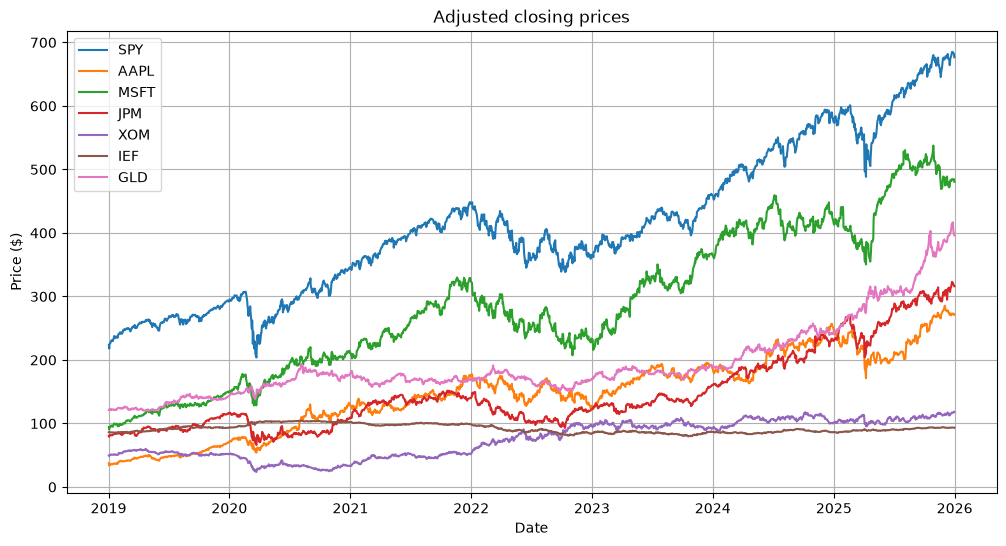

In [6]:
#plotting prices
plt.figure(figsize=(12, 6))
for ticker in tickers:
    plt.plot(prices.index, prices[ticker], label=ticker)

plt.title("Adjusted closing prices")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.show()

Value of $100 invested at the start:
SPY 303.08
AAPL 724.21
MSFT 511.16
JPM 394.8
XOM 239.08
IEF 108.22
GLD 326.64


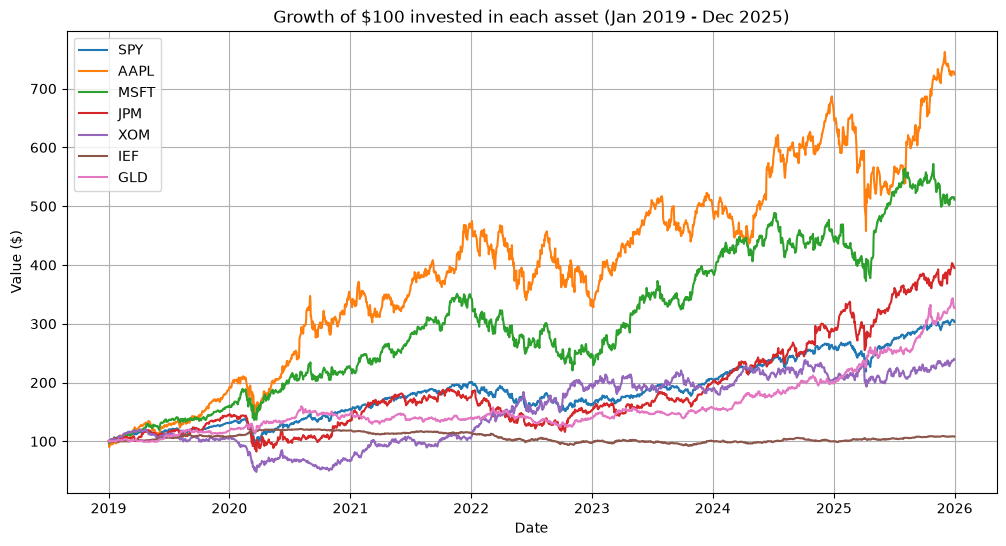

In [7]:
# starting every asset at 100 so they can be compared fairly
normalised_prices = pd.DataFrame()
for ticker in tickers:
    first_price = prices[ticker].iloc[0]
    normalised_prices[ticker] = prices[ticker] / first_price * 100

print("Value of $100 invested at the start:")
for ticker in tickers:
    final_value = normalised_prices[ticker].iloc[-1]
    print(ticker, round(final_value, 2))

plt.figure(figsize=(12, 6))
for ticker in tickers:
    plt.plot(normalised_prices.index, normalised_prices[ticker], label=ticker)

plt.title("Growth of $100 invested in each asset (Jan 2019 - Dec 2025)")
plt.xlabel("Date")
plt.ylabel("Value ($)")
plt.legend()
plt.grid(True)
# save the chart so I can use it in the README later
plt.savefig("growth_of_100.png")
plt.show()

In [8]:
#Daily returns

returns = pd.DataFrame()
for ticker in tickers:
    returns[ticker] = prices[ticker].pct_change()

# first row empty as no previoys day to compare
returns = returns.dropna()

print(returns.head())
print("Number of daily returns:", len(returns))

                 SPY      AAPL      MSFT       JPM       XOM       IEF  \
Date                                                                     
2019-01-03 -0.023863 -0.099607 -0.036788 -0.014212 -0.015354  0.007949   
2019-01-04  0.033496  0.042689  0.046509  0.036866  0.036870 -0.008076   
2019-01-07  0.007884 -0.002226  0.001275  0.000695  0.005200 -0.002777   
2019-01-08  0.009396  0.019063  0.007251 -0.001886  0.007271 -0.002497   
2019-01-09  0.004673  0.016982  0.014299 -0.001690  0.005275  0.000578   

                 GLD  
Date                  
2019-01-03  0.009066  
2019-01-04 -0.008086  
2019-01-07  0.003458  
2019-01-08 -0.002708  
2019-01-09  0.006418  
Number of daily returns: 1759


In [9]:
print("Daily return statistics:")
for ticker in tickers:
    average = returns[ticker].mean() * 100
    best = returns[ticker].max() * 100
    worst = returns[ticker].min() * 100
    best_date = returns[ticker].idxmax()
    worst_date = returns[ticker].idxmin()
    print(ticker)
    print("  average daily return:", round(average, 3), "%")
    print("  best day:", round(best, 2), "% on", best_date.date())
    print("  worst day:", round(worst, 2), "% on", worst_date.date())

Daily return statistics:
SPY
  average daily return: 0.071 %
  best day: 10.5 % on 2025-04-09
  worst day: -10.94 % on 2020-03-16
AAPL
  average daily return: 0.132 %
  best day: 15.33 % on 2025-04-09
  worst day: -12.86 % on 2020-03-16
MSFT
  average daily return: 0.109 %
  best day: 14.22 % on 2020-03-13
  worst day: -14.74 % on 2020-03-16
JPM
  average daily return: 0.096 %
  best day: 18.01 % on 2020-03-13
  worst day: -14.96 % on 2020-03-16
XOM
  average daily return: 0.069 %
  best day: 12.69 % on 2020-03-24
  worst day: -12.22 % on 2020-03-09
IEF
  average daily return: 0.006 %
  best day: 2.64 % on 2020-03-16
  worst day: -2.51 % on 2020-03-17
GLD
  average daily return: 0.072 %
  best day: 4.85 % on 2020-03-24
  worst day: -6.43 % on 2025-10-21


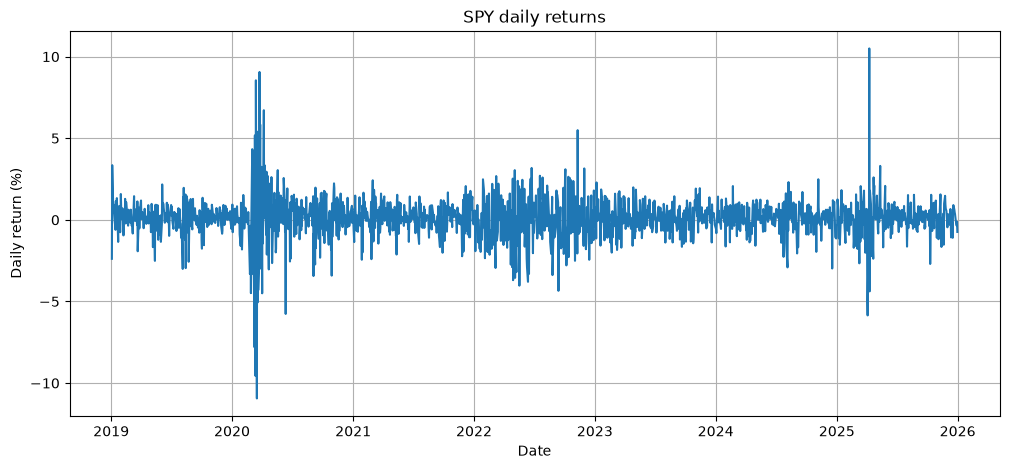

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(returns.index, returns["SPY"] * 100)
plt.title("SPY daily returns")
plt.xlabel("Date")
plt.ylabel("Daily return (%)")
plt.grid(True)
plt.show()

In [11]:
#portfolio returns
# each day the portfolio return is the weighted average of the asset returns
portfolio_returns = 0
for ticker in tickers:
    portfolio_returns = portfolio_returns + returns[ticker] * portfolio_weights[ticker]

print(portfolio_returns.head())

Date
2019-01-03   -0.021259
2019-01-04    0.023918
2019-01-07    0.002650
2019-01-08    0.005218
2019-01-09    0.005646
dtype: float64


Final value of $100,000:
My portfolio: 317428
S&P 500 (SPY): 303082


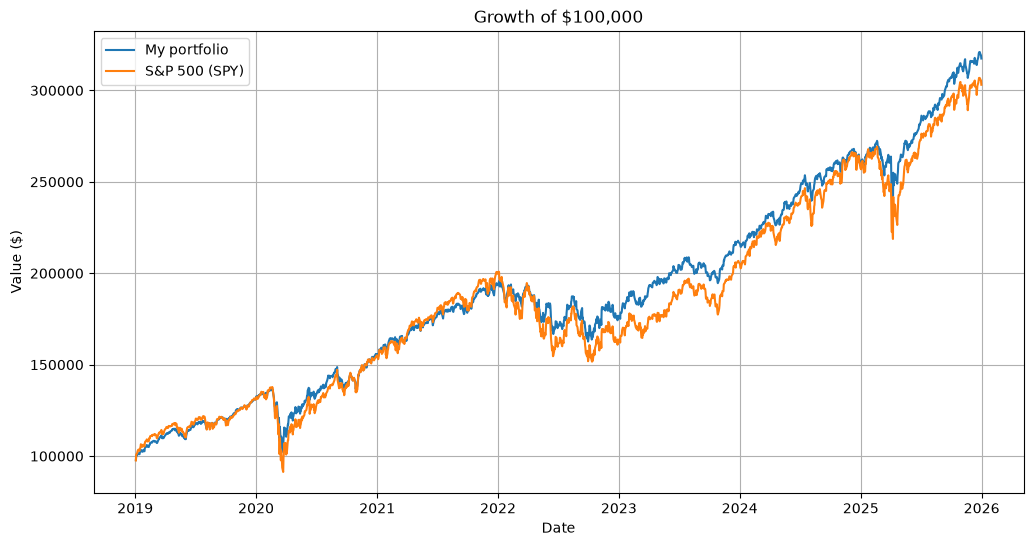

In [12]:
#growth of $100,000
def calculate_growth(daily_returns, starting_value):
    values = []
    value = starting_value
    for daily_return in daily_returns:
        value = value * (1 + daily_return)
        values.append(value)
    return pd.Series(values, index=daily_returns.index)

portfolio_growth = calculate_growth(portfolio_returns, portfolio_value)
spy_growth = calculate_growth(returns["SPY"], portfolio_value)

print("Final value of $100,000:")
print("My portfolio:", round(portfolio_growth.iloc[-1]))
print("S&P 500 (SPY):", round(spy_growth.iloc[-1]))

plt.figure(figsize=(12, 6))
plt.plot(portfolio_growth.index, portfolio_growth, label="My portfolio")
plt.plot(spy_growth.index, spy_growth, label="S&P 500 (SPY)")
plt.title("Growth of $100,000")
plt.xlabel("Date")
plt.ylabel("Value ($)")
plt.legend()
plt.grid(True)
plt.savefig("portfolio_growth.png")
plt.show()

In [13]:
#annualised return
number_of_years = len(portfolio_returns) / 252

portfolio_total_growth = portfolio_growth.iloc[-1] / portfolio_value
portfolio_annual_return = portfolio_total_growth ** (1 / number_of_years) - 1

spy_total_growth = spy_growth.iloc[-1] / portfolio_value
spy_annual_return = spy_total_growth ** (1 / number_of_years) - 1

print("Number of years:", round(number_of_years, 2))
print("My portfolio:", round(portfolio_annual_return * 100, 2), "%")
print("S&P 500 (SPY):", round(spy_annual_return * 100, 2), "%")

Number of years: 6.98
My portfolio: 18.0 %
S&P 500 (SPY): 17.22 %


In [14]:
#calculating volatility
# times the square root of 252 to turn daily volatility into yearly
print("Annualised volatility:")
for ticker in tickers:
    volatility = returns[ticker].std() * np.sqrt(252)
    print(ticker, round(volatility * 100, 2), "%")

portfolio_volatility = portfolio_returns.std() * np.sqrt(252)
spy_volatility = returns["SPY"].std() * np.sqrt(252)

print()
print("My portfolio:", round(portfolio_volatility * 100, 2), "%")
print("S&P 500 (SPY):", round(spy_volatility * 100, 2), "%")

Annualised volatility:
SPY 19.78 %
AAPL 31.08 %
MSFT 28.37 %
JPM 29.89 %
XOM 31.14 %
IEF 7.34 %
GLD 15.76 %

My portfolio: 14.9 %
S&P 500 (SPY): 19.78 %


       SPY  AAPL  MSFT   JPM   XOM   IEF   GLD
SPY   1.00  0.78  0.80  0.71  0.51 -0.11  0.11
AAPL  0.78  1.00  0.70  0.42  0.30 -0.06  0.07
MSFT  0.80  0.70  1.00  0.43  0.25 -0.07  0.07
JPM   0.71  0.42  0.43  1.00  0.55 -0.26 -0.03
XOM   0.51  0.30  0.25  0.55  1.00 -0.21  0.06
IEF  -0.11 -0.06 -0.07 -0.26 -0.21  1.00  0.33
GLD   0.11  0.07  0.07 -0.03  0.06  0.33  1.00


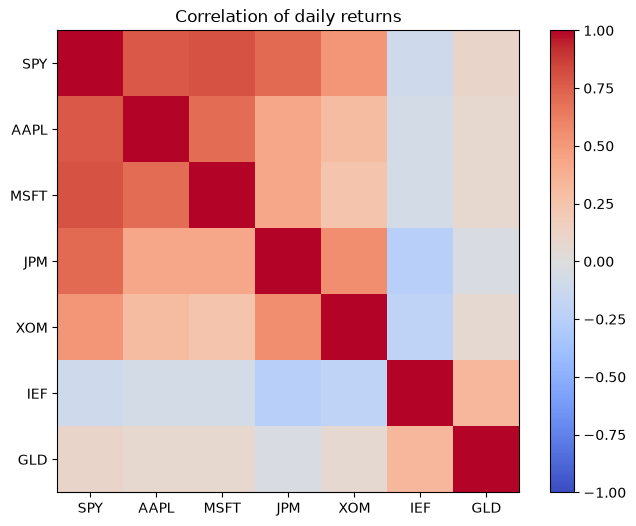

In [15]:
#correlation matrix
correlation_matrix = returns.corr()
print(correlation_matrix.round(2))

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(tickers)), tickers)
plt.yticks(range(len(tickers)), tickers)
plt.title("Correlation of daily returns")
plt.savefig("correlation_matrix.png")
plt.show()

In [16]:
#sharpe ratio
# roughly the average US treasury bill rate 2019-2025
risk_free_rate = 0.025

portfolio_sharpe = (portfolio_annual_return - risk_free_rate) / portfolio_volatility
spy_sharpe = (spy_annual_return - risk_free_rate) / spy_volatility

print("Sharpe ratio:")
print("My portfolio:", round(portfolio_sharpe, 2))
print("S&P 500 (SPY):", round(spy_sharpe, 2))

Sharpe ratio:
My portfolio: 1.04
S&P 500 (SPY): 0.74


Maximum drawdown: -25.3 %


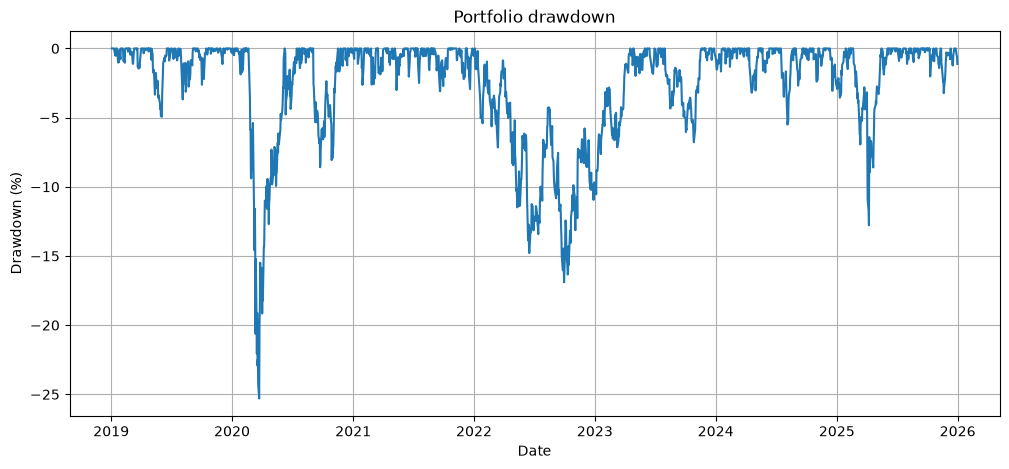

In [17]:
#drawdown - how far below its highest value the portfolio is
peak = portfolio_growth.iloc[0]
drawdowns = []
for value in portfolio_growth:
    if value > peak:
        peak = value
    drawdown = (value / peak - 1) * 100
    drawdowns.append(drawdown)

print("Maximum drawdown:", round(min(drawdowns), 2), "%")

plt.figure(figsize=(12, 5))
plt.plot(portfolio_growth.index, drawdowns)
plt.title("Portfolio drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(True)
plt.show()

In [18]:
#value at risk
# 5th percentile = only 5% of days were worse than this
var_95 = np.percentile(portfolio_returns, 5)

print("1-day 95% VaR:", round(var_95 * 100, 2), "%")
print("On $100,000 that is a loss of about $", round(-var_95 * portfolio_value))

1-day 95% VaR: -1.28 %
On $100,000 that is a loss of about $ 1283


In [19]:
#comparing different weights
weight_sets = {
    "My portfolio (70/30)": portfolio_weights,
    "Stocks only": {"SPY": 0.40, "AAPL": 0.15, "MSFT": 0.15, "JPM": 0.15, "XOM": 0.15, "IEF": 0, "GLD": 0},
    "Conservative (40/60)": {"SPY": 0.20, "AAPL": 0.05, "MSFT": 0.05, "JPM": 0.05, "XOM": 0.05, "IEF": 0.45, "GLD": 0.15},
}

for name in weight_sets:
    weights = weight_sets[name]

    daily_returns = 0
    for ticker in tickers:
        daily_returns = daily_returns + returns[ticker] * weights[ticker]

    growth = calculate_growth(daily_returns, portfolio_value)
    annual_return = (growth.iloc[-1] / portfolio_value) ** (1 / number_of_years) - 1
    volatility = daily_returns.std() * np.sqrt(252)
    one_day_var = np.percentile(daily_returns, 5)

    print(name)
    print("   annual return:", round(annual_return * 100, 2), "%")
    print("   volatility:", round(volatility * 100, 2), "%")
    print("   1-day 95% VaR:", round(one_day_var * 100, 2), "%")

My portfolio (70/30)
   annual return: 18.0 %
   volatility: 14.9 %
   1-day 95% VaR: -1.28 %
Stocks only
   annual return: 22.36 %
   volatility: 21.25 %
   1-day 95% VaR: -1.83 %
Conservative (40/60)
   annual return: 12.3 %
   volatility: 9.28 %
   1-day 95% VaR: -0.83 %


In [20]:
#stress test - what if equities suddenly fall
# assuming bonds and gold don't change
equity_falls = [-0.10, -0.15, -0.20]

for fall in equity_falls:
    portfolio_change = 0
    for ticker in tickers:
        if asset_classes[ticker] == "Equity":
            portfolio_change = portfolio_change + portfolio_weights[ticker] * fall

    print("Equity shock:", round(fall * 100), "%")
    print("   portfolio changes by", round(portfolio_change * 100, 2), "%, or $", round(portfolio_change * portfolio_value))

Equity shock: -10 %
   portfolio changes by -7.0 %, or $ -7000
Equity shock: -15 %
   portfolio changes by -10.5 %, or $ -10500
Equity shock: -20 %
   portfolio changes by -14.0 %, or $ -14000
